# Phase 2: Linear Probing for Gender Detection

This notebook implements linear probing to investigate how gender information is encoded across different layers of a language model. The goal is to understand at which depth the model develops representations that correlate with the author's gender.

## Environment Setup and Model Loading

We start by authenticating with Hugging Face and loading the Gemma model. That way
we can access the model weights.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

from huggingface_hub import login
login(token=os.getenv("HUGGING_FACE_TOKEN"))

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import numpy as np

/Users/pierre/EPITA/ING3/NLP/repo/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_id = "google/gemma-3-270m"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id, 
    output_hidden_states=True, 
    dtype=torch.float32,
    device_map="auto"
)

The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


## Hidden States Extraction

The function below extracts hidden states from all layers of the model. For each input prompt, we:
1. Tokenize the text and pass it through the model
2. Collect the hidden state from each layer (including the embedding layer)
3. Extract only the last token's representation, which captures the full context of the input

This gives us a set of vectors for each layer that we can use to train our linear probes.

In [3]:
def extract_hidden_states(prompts, model, tokenizer):
    model.eval()
    all_layers_data = {i: [] for i in range(model.config.num_hidden_layers + 1)}

    with torch.no_grad():
        for text in prompts:
            inputs = tokenizer(text, return_tensors="pt").to(model.device)
            outputs = model(**inputs)

            for layer_idx, layer_tensor in enumerate(outputs.hidden_states):
                last_token_vector = layer_tensor[0, -1, :].cpu().numpy()
                all_layers_data[layer_idx].append(last_token_vector)
                
    return all_layers_data

## Sample Dataset

We define a small set of the hard gender detection blog posts with their labels to test our probing approach. These samples come from the `phase_1_data_prep.ipynb` notebook.

Labels:
- 1 for `female`
- 0 for `male`

This is a proof-of-concept with a limited number of samples. In a full experiment, we would use the filtered dataset from Phase 1.

In [4]:
prompts = [
    "HAZEL EYES. close your eyes and imagine a lake without water, imagine a tree without leaves, imagine the moon without stars, imagine a leaf lying worthless on the ground, imagine a body withou HEART. close your eyes again and imagine me lonely, alone among thousand people. no-one to share joy and pain, no-true friends and nothing to gain, leading a life which is smooth but dark, trying to forget the memories of morning lark. close your eyes again imagine yourself standing on a shore, under a palm tree, behind you are the mountains, feeling sad and bore. waiting for someone to appear from the sea, gives you a blessing , and sets you free. imagine a flower without its colour, AND THAT'S HOW I FEEL WITHOUT YOU. overcome your grief, stand tall and save the lake to turn barren, save the tree to turn fossil, save the moon to turn alone, save the leaf before anyone steps on it, save the body before it dies.... ---nil", 
    "LET IT BE ME. a bird hibernated for a year or so, her first flight, after her feathers grow. sparkled from the sunlight were her eyes, she forgot her mainland and she flies and flies. created new friends, created new foes, memories of her mainland finally goes. forgot her hometown, forgot her trust, forgot the first book of love, whose love was just. week gradually passed, eighth day was pleasure, ninth day was fun, tenth day was leisure. the eleventh day was a pause in her life, she had a pool of memories, in which she dive. she cried for her friends, she cried for her foes , she cried for her mainland whose memory never goes. she cried for her hometown, she cried for her trust , she cried for her first love , whose love was just . she now takes challenges, each day as a goal, feeling hostile , away from her home. sparkled from the tears, were her eyes, she remembers her mainland and she cries and cries, no true friends and no true foes, memories of her mainland never goes... --- nil you can mail me by clicking- mailto:swapnilmail123@rediffmail.com",
    "It's my first Mambo!   So let's get ourselves warmed up and dance, shall we, with a little \"I say...You think...\" Magazine: People Photo: camera Concert: music Video: killed the radio star Pass: backstage! Ticket: master Line: dance Excitement: fun! Are you warmed up yet? That's good, cos the Mambo Guy is getting impatient. He wants to get his mambo going on. So let's get started. 1. If you had backstages passes to the show of your chosing, who would it be, and what would you do once you were backstage? (Try to be clean.)  B ackstage with The Cure, and I would ask Robert Smith who does his makeup! 2. What entertainment magazines do you read? People, US Weekly, Entertainment Weekly, Rolling Stone 3. Do you read concert/album reviews in your local newspaper? And if so, do you let the review sway your opinion on the band/album? No, because the main reviewer of our city's newspaper never really has something nice to say about anyone except for Lucinda Williams. 4. Create your dream concert lineup. (a sort of Lollapalooza event of your making). Oh, geez. There are millions. Jet, the Cure, Coldplay, the Eagles, the Steve Miller Band, Journey, Van Halen (Hagar, not Roth), Duran Duran, Def Leppard, Allison Moorer, Shelby Lynne, Aimee Mann... 5. If you could have attended any festival show at any time...From Woodstock on...which one would it have been, and why? I wouldn't have minded going to Lilith Fair when it was still around, but I was too young at the time to go. Chicks rule! I love to Mambo!!!!",
    "Mum had tore a leg ligament and broke her smallest toe bone a few days ago...so she is in crutches and limps about wherever she goes...wow...didnt expect it to happen...but the unexpected happened....she takes like longer ( yes, longer than her usual time, which is already long) to do basic stuff like changing clothes....she can take about one hour ! my poor mum...hope she gets well soon ! till then im her nursing assistant ! Well went for my J-train meeting today at TBSC...it was...awesome...the people are so nice there....especially the sd peeps...haha...as if i dunno in the first place anyway.... then i met this really nice gal, who is 20 this year and we actually took a bus ride (1 1/2 hours) and talked about everthing under the sun ! wow...she is super nice, yeah and i think we can really relate to in many levels...except physically...as it may be quite nightmarish and mentally disturbing to me...hahahaha kidding ! but seriously...this gal huh...is so full of life and jumpy and like those happy-go-lucky sort of gal...hahah...very sweet....dont think she's doing it for the sake of entertaining me though...so i guess she's sincere...hahah...that's cool...how many of these type of peeps do you meet in ur lifetime ? Rowena's the name. yeah came back around nine....tired....sleepy....hmmm...wahts new....oh yeah i have not even touched my art which i have to pass tomorrow...gonna die....good night.",
    "When you'd cry i'd wipe away all of your tears, when you'd scream i'd fight away all of your fears, I held your hand through all of these years, But you still have,all of me. Err..no prizes for guessing whats the title of this song(in case you dont know,it's My Immortal by Evanessance)... Dedicated to no one in particular, jus had this song running over and over again my head. Being single, its perfectly normal to be thinking of all these kinds of stupid things...hahah..its kind of hard to like someone but not let the person know huh? but...being me as usual, i'll just wait and see how things go, never making the first move,yet quietly dropping hints to be picked up.Yet i know it may be just my puberty-induced hormones creating infactuastic-love commotion in my life to make it more interesting...but i'll still wait for a while more i guess...a little while more.. Today was tiring.Skool started again for the June Hols...and it dosen't end till the second last week of the hols...like i said, what holidays ? I seriously think the skool has some issues. What if we study too much and just before the O's we become mentally retarded ? would they be happy then? Then my future will be gone ! haha....but seriously, O level year is no life man...but, looking far ahead, i ACTUALLY needed the extra lessons ( wow, i cant believe im saying this !)if i want my distinctions so that's the bottom line. No complaining anymore. But i have to tell you, the teachers that are teaching me are great.. I mean, how can you find a group of approachable and down-to-earth teachers in a bundle (teachers like Miss Lee, Wendy, Cindy....it goes on)? so i guess thats my good fortune and i have to make good use of it ! Wendy Loi came up to me today while ordering food. She actually told me it is possible for me to get a distinction. Checking if she may have been drunk or may have mixed my identity with some first express class student with thick glasses holding a thick book wherever he goes, i realised that she was looking me straight in the eye. I was like....oh okay cool ! i can actually get a distinction ! if i work at it,that is. I never realise that she thought i had potential. Therefore this spurs me to do better in my POA. hahah...yeah thats about it for today then...boring life i have here... Sign out.",
    "I have discovered Krispey Kremes donuts, and the lord proclaimed: they are GOOD! I found them in Harrods yesterday when I popped in to see if I could buy any of those sausages from Jimmy's Farm (unlikely, as I couldn't remember his name) and bought a box for me and Si to share. They disappeared quickly. Well...my interview yesterday. I can honestly say I don't know how it went, which probably means it didn't go all that well. Let's face it, if you're not coming out of an interview filled with confidence it's unlikely you got the job. The first bit went well, when I was telling them about my skills and qualifications. They seemed impressed, and I even made them laugh a few times. Then when it came to job-specific skills they started asking me such basic questions that I was a little gob-smacked. I'm sure there were lots of awkward silences as my brain desperately asked itself: is this a trick question? I probably came across as a complete moron. I think I did ok on the skills test though. All I can do now is wait. I should know by next week. I also have to finish my on-line application form for the market researchers job, but I can't remember the web address so I'll have to search for that one. Other than that, I popped into the British museum for an hour and saw the costumes used in the film Troy: they were cool. I also visited my houses of worship: Monsoon and Lush. They symbolize cool London living to me. I played a few rounds of my least favourite game: tube hopping (where you get on a tube then off at the next stop, then realise you got off at the wrong stop and wait for the next one.) The train ride home was ok, although I didn't get back 'til gone midnight. Having said that, I wasn't very tired. See, I can cope with the London lifestyle. Today was a good day at work. Everyone seems so relaxed and happy. I've found the kids to be very pleasant company. I think I'll miss them more than I thought. I know they will miss me. Today was also the lesson I'd been planning with Carol. She came in and gave a lovely speech about how great the class was, questioned them about their recent work and they did me proud. Then she revealed she was wearing my 'Snitch for President' t-shirt, which got a big cheer. Then we handed out bars of chocolate and awards to the students: I gave out the fimo rats I'd made some students. They were incredibly touched. It was very heart-warming. Right, I have to go back to the osteopath now (and not a minute too soon).",
    "I know, another quote...but I especially like this one. I believe this calls for a special shout-out to \"Double Trouble\"! A good friend will come and bail you out of jail...but, a true friend will be sitting next to you saying, \"Damn...that was fun!\"",
    "I am so over Kevin. But as for the Carmicheal situation, this looks like it will become a force to be reckoned with.",
    "Hmmmm. I'll try to re-capture my fleeting thoughts. Am I afraid of being alone? No. Not to get philosphical, but ultimately, each of us is alone. I think we're all trying to find someone to share our life experience with. So while I'm not afraid to be alone, I would prefer to be sharing my life with someone beyond just myself. We each came to meet one another most likely not at our ideal time. I was originally focused on my situation and my history and my baggage (for lack of a better word), which I guess is natural, because I see the world from my viewpoint, primarily. But my main concern, was whether or not I was ready and whether or not I was good enough for you and a relationship with you.  I mean of course I'm always judging what's going on around me, seeing how it fits into my world. But I didn't originally think about whether or not you were ready for a relationship, or your situation and history, or your baggage.  More of that stuff has come out -- how he wounded you, and how you're coping with your past (relationships, childhood, parents, friendships) -- all the things that you're dealing with, and likewise, you're trying to see how I fit into your world. The key is for each of us to be completely honest with ourselves and with each other about everything we're feeling. And that's rarely easy to do. You were right when you said that I married young -- I definitely rushed into it -- and constantly regretted it. I'm going to be more careful this time around. That means a longer dating period. The key for me is to look beyond my infatuation to determine whether or not we'll be good, long term, as mates. Laima was my first, real, long term relationship. I was infatuated and I rushed into marriage. Actually, I was just excited that I found someone who was actually interested in me.  So while I'm looking beyond the infatuation, I'm also working at not losing sight of, or failing to experience those very infatuation-related feelings (because they feel great!) I've really enjoyed our dating so far. I feel really comfortable with you and I feel like you're looking out for my best interests. I feel free. I mean we went away together for the weekend and had a great time. I was sick on Saturday and you were still accepting of me. I don't recall having those feelings with L, or particularly enjoying our dating back then. There is some small part of me that is afraid of getting betrayed again -- of putting too much trust into another individual. But that's all about me, and nothing about you. What I mean by that is that there is nothing you can say or do that will help me with these feelings, and it has nothing to do with who you are or what you've done in your past. It's more of an issue that I need to work on. At some point we'll stop seeing the world so much from our individual perspectives and we'll start seeing the world from our couple perspective. As a team we'll tackle problems together, we'll experience life together, we'll share our individual experiences with each other, we'll grow together. Well, I think I've rambled on enough, and gone in enough different directions.",
    "Porcelain by Moby (The Beach Soundtrack) .... Costa Rica again, but this time feels sad, and reminds me of the sad feelings and feelings of the end of a chapter in my life. Of L lying to me and hurting me over and over again. In my dreams I'm dying all the time As I wake its kaleidoscopic mind I never meant to hurt you I never meant to lie So this is goodbye This is goodbye Tell the truth you never wanted me Tell me In my dreams I'm jealous all the time As I wake I'm going out of my mind Going out of my mind"
]

# 1 for female, and 0 for male
labels = [0, 0, 1, 0, 0, 1, 1, 1, 0, 0]

data_per_layer = extract_hidden_states(prompts, model, tokenizer)

## Training Linear Probes

For each layer, we train a Logistic Regression classifier to predict gender from the hidden state vectors. We use cross-validation to estimate the accuracy of each layer's representations.

A layer with high accuracy suggests that gender-related information is linearly separable in that layer's representation space.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

layer_accuracies = []

for layer_idx, vectors in data_per_layer.items():
    X = np.array(vectors)
    y = np.array(labels)

    clf = LogisticRegression(max_iter=1000)
    scores = cross_val_score(clf, X, y, cv=2)
    
    avg_acc = scores.mean()
    layer_accuracies.append(avg_acc)
    print(f"Layer {layer_idx}: Gender precision = {avg_acc:.2%}")

Layer 0: Gender precision = 70.00%
Layer 1: Gender precision = 70.00%
Layer 2: Gender precision = 80.00%
Layer 3: Gender precision = 60.00%
Layer 4: Gender precision = 80.00%
Layer 5: Gender precision = 60.00%
Layer 6: Gender precision = 50.00%
Layer 7: Gender precision = 40.00%
Layer 8: Gender precision = 50.00%
Layer 9: Gender precision = 60.00%
Layer 10: Gender precision = 50.00%
Layer 11: Gender precision = 60.00%
Layer 12: Gender precision = 50.00%
Layer 13: Gender precision = 60.00%
Layer 14: Gender precision = 60.00%
Layer 15: Gender precision = 60.00%
Layer 16: Gender precision = 60.00%
Layer 17: Gender precision = 60.00%
Layer 18: Gender precision = 60.00%


## Visualization of Layer-wise Accuracy

We plot the classification accuracy for each layer to visualize where gender information emerges in the model. The red dashed line at 50% represents random chance (baseline for binary classification).

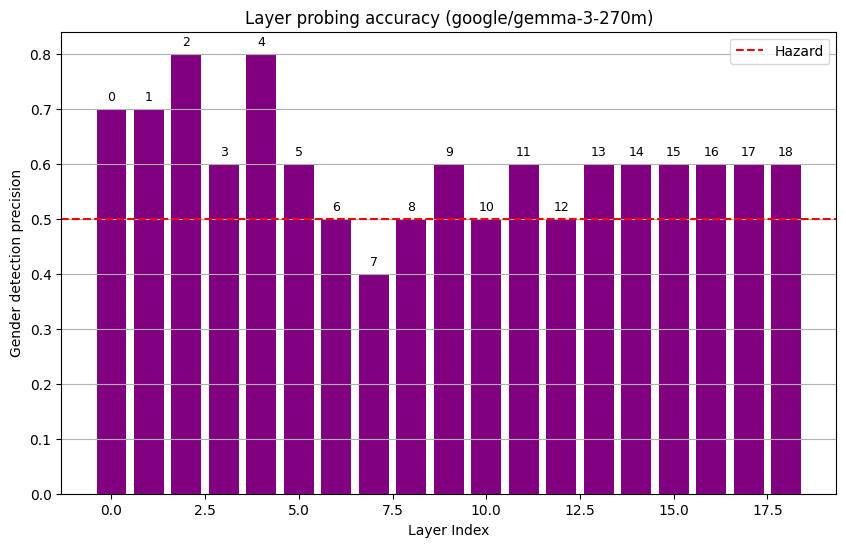

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(layer_accuracies)), layer_accuracies, color='purple')
plt.title(f"Layer probing accuracy ({model_id})")
plt.xlabel("Layer Index")
plt.ylabel("Gender detection precision")
plt.axhline(y=0.5, color='r', linestyle='--', label="Hazard")

for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, str(i), 
             ha='center', va='bottom', fontsize=9)

plt.legend()
plt.grid(True, axis='y')
plt.show()

On the previous graph we can see layers with an accuracy significantly above 50% : they might contain useful gender-related features. 

From these prompts, we can see how the model generalize and use the gender information. They averaged 60% so we are not completly sure of the gender of the user.